In [3]:
import geopandas as gpd
import pandas as pd
import glob

# 1. 모든 txt 파일에서 고령 인구 데이터 만들기 (이전과 동일)
txt_files = glob.glob("./10km/txt_data/*.txt")
df_list = []

for file in txt_files:
    df = pd.read_csv(file, sep="\\^", header=None, engine="python")
    df.columns = ["year", "grid_id", "age_code", "count"]
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
df_all["age"] = df_all["age_code"].str.extract(r"in_age_(\d+)")[0].astype(float)
df_all = df_all.dropna(subset=["age"])
df_all["age"] = df_all["age"].astype(int)
df_elder = df_all[df_all["age"] >= 65]
df_elder_sum = df_elder.groupby("grid_id")["count"].sum().reset_index()
df_elder_sum.columns = ["GRID_10K_C", "elderly_pop"]

# 2. 모든 grid_XX_10K.shp 병합
shp_files = glob.glob("./10km/grid/grid_*_10K.shp")  # 폴더 경로에 맞게 수정
gdf_list = [gpd.read_file(shp) for shp in shp_files]
gdf_all = pd.concat(gdf_list, ignore_index=True)

# 3. 고령 인구 병합
gdf_all = gdf_all.merge(df_elder_sum, on="GRID_10K_C", how="left")
gdf_all["elderly_pop"] = gdf_all["elderly_pop"].fillna(0).astype(int)

# 4. 저장
gdf_all.to_file("grid_with_elderly_10K.gpkg", driver="GPKG")
print("✅ 전국 격자 + 고령 인구 결합 완료 → grid_with_elderly_10K.geojson 저장됨")

✅ 전국 격자 + 고령 인구 결합 완료 → grid_with_elderly_10K.geojson 저장됨


In [4]:
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# 1. 격자 및 병원 데이터 불러오기
gdf_grid = gpd.read_file("grid_with_elderly_10K.gpkg")
gdf_grid = gdf_grid.to_crs(epsg=5181)  # 미터 단위 좌표계로 변환

# 병원 예시 데이터
hospital_data = pd.read_csv("hospitals.csv")  # 또는 위에서 만든 hospital_data 사용
hospital_data["geometry"] = hospital_data.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
gdf_hosp = gpd.GeoDataFrame(hospital_data, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:5181")

# 버퍼 거리 설정 (예: 10km = 10000m)
BUFFER_RADIUS = 10000

# 2SFCA Step 1: 병원 중심으로 10km 내 인구 합산 후 공급비율 계산
ratios = []
for idx, hosp in gdf_hosp.iterrows():
    buffer = hosp.geometry.buffer(BUFFER_RADIUS)
    nearby_grids = gdf_grid[gdf_grid.geometry.intersects(buffer)]
    total_pop = nearby_grids["elderly_pop"].sum()
    ratio = hosp["doctors"] / total_pop if total_pop > 0 else 0
    ratios.append(ratio)

gdf_hosp["supply_ratio"] = ratios

# Step 2: 격자 중심으로 10km 내 병원들의 공급비율 합산
accessibility_scores = []
for idx, grid in gdf_grid.iterrows():
    buffer = grid.geometry.centroid.buffer(BUFFER_RADIUS)
    nearby_hosp = gdf_hosp[gdf_hosp.geometry.intersects(buffer)]
    score = nearby_hosp["supply_ratio"].sum()
    accessibility_scores.append(score)

gdf_grid["accessibility_index"] = accessibility_scores

# # 저장
# gdf_grid.to_file("grid_with_accessibility_10K.gpkg", driver="GPKG")
# print("✅ 2SFCA 계산 완료 → grid_with_accessibility_10K.gpkg 저장됨")


C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\2003157722.py:29: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\2003157722.py:29: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\2003157722.py:29: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\2003157722.py:29: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\2003157722.py:29: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\2003157722.py:29: UserWarning: Glyph 44592 (\N{HANGUL SYL

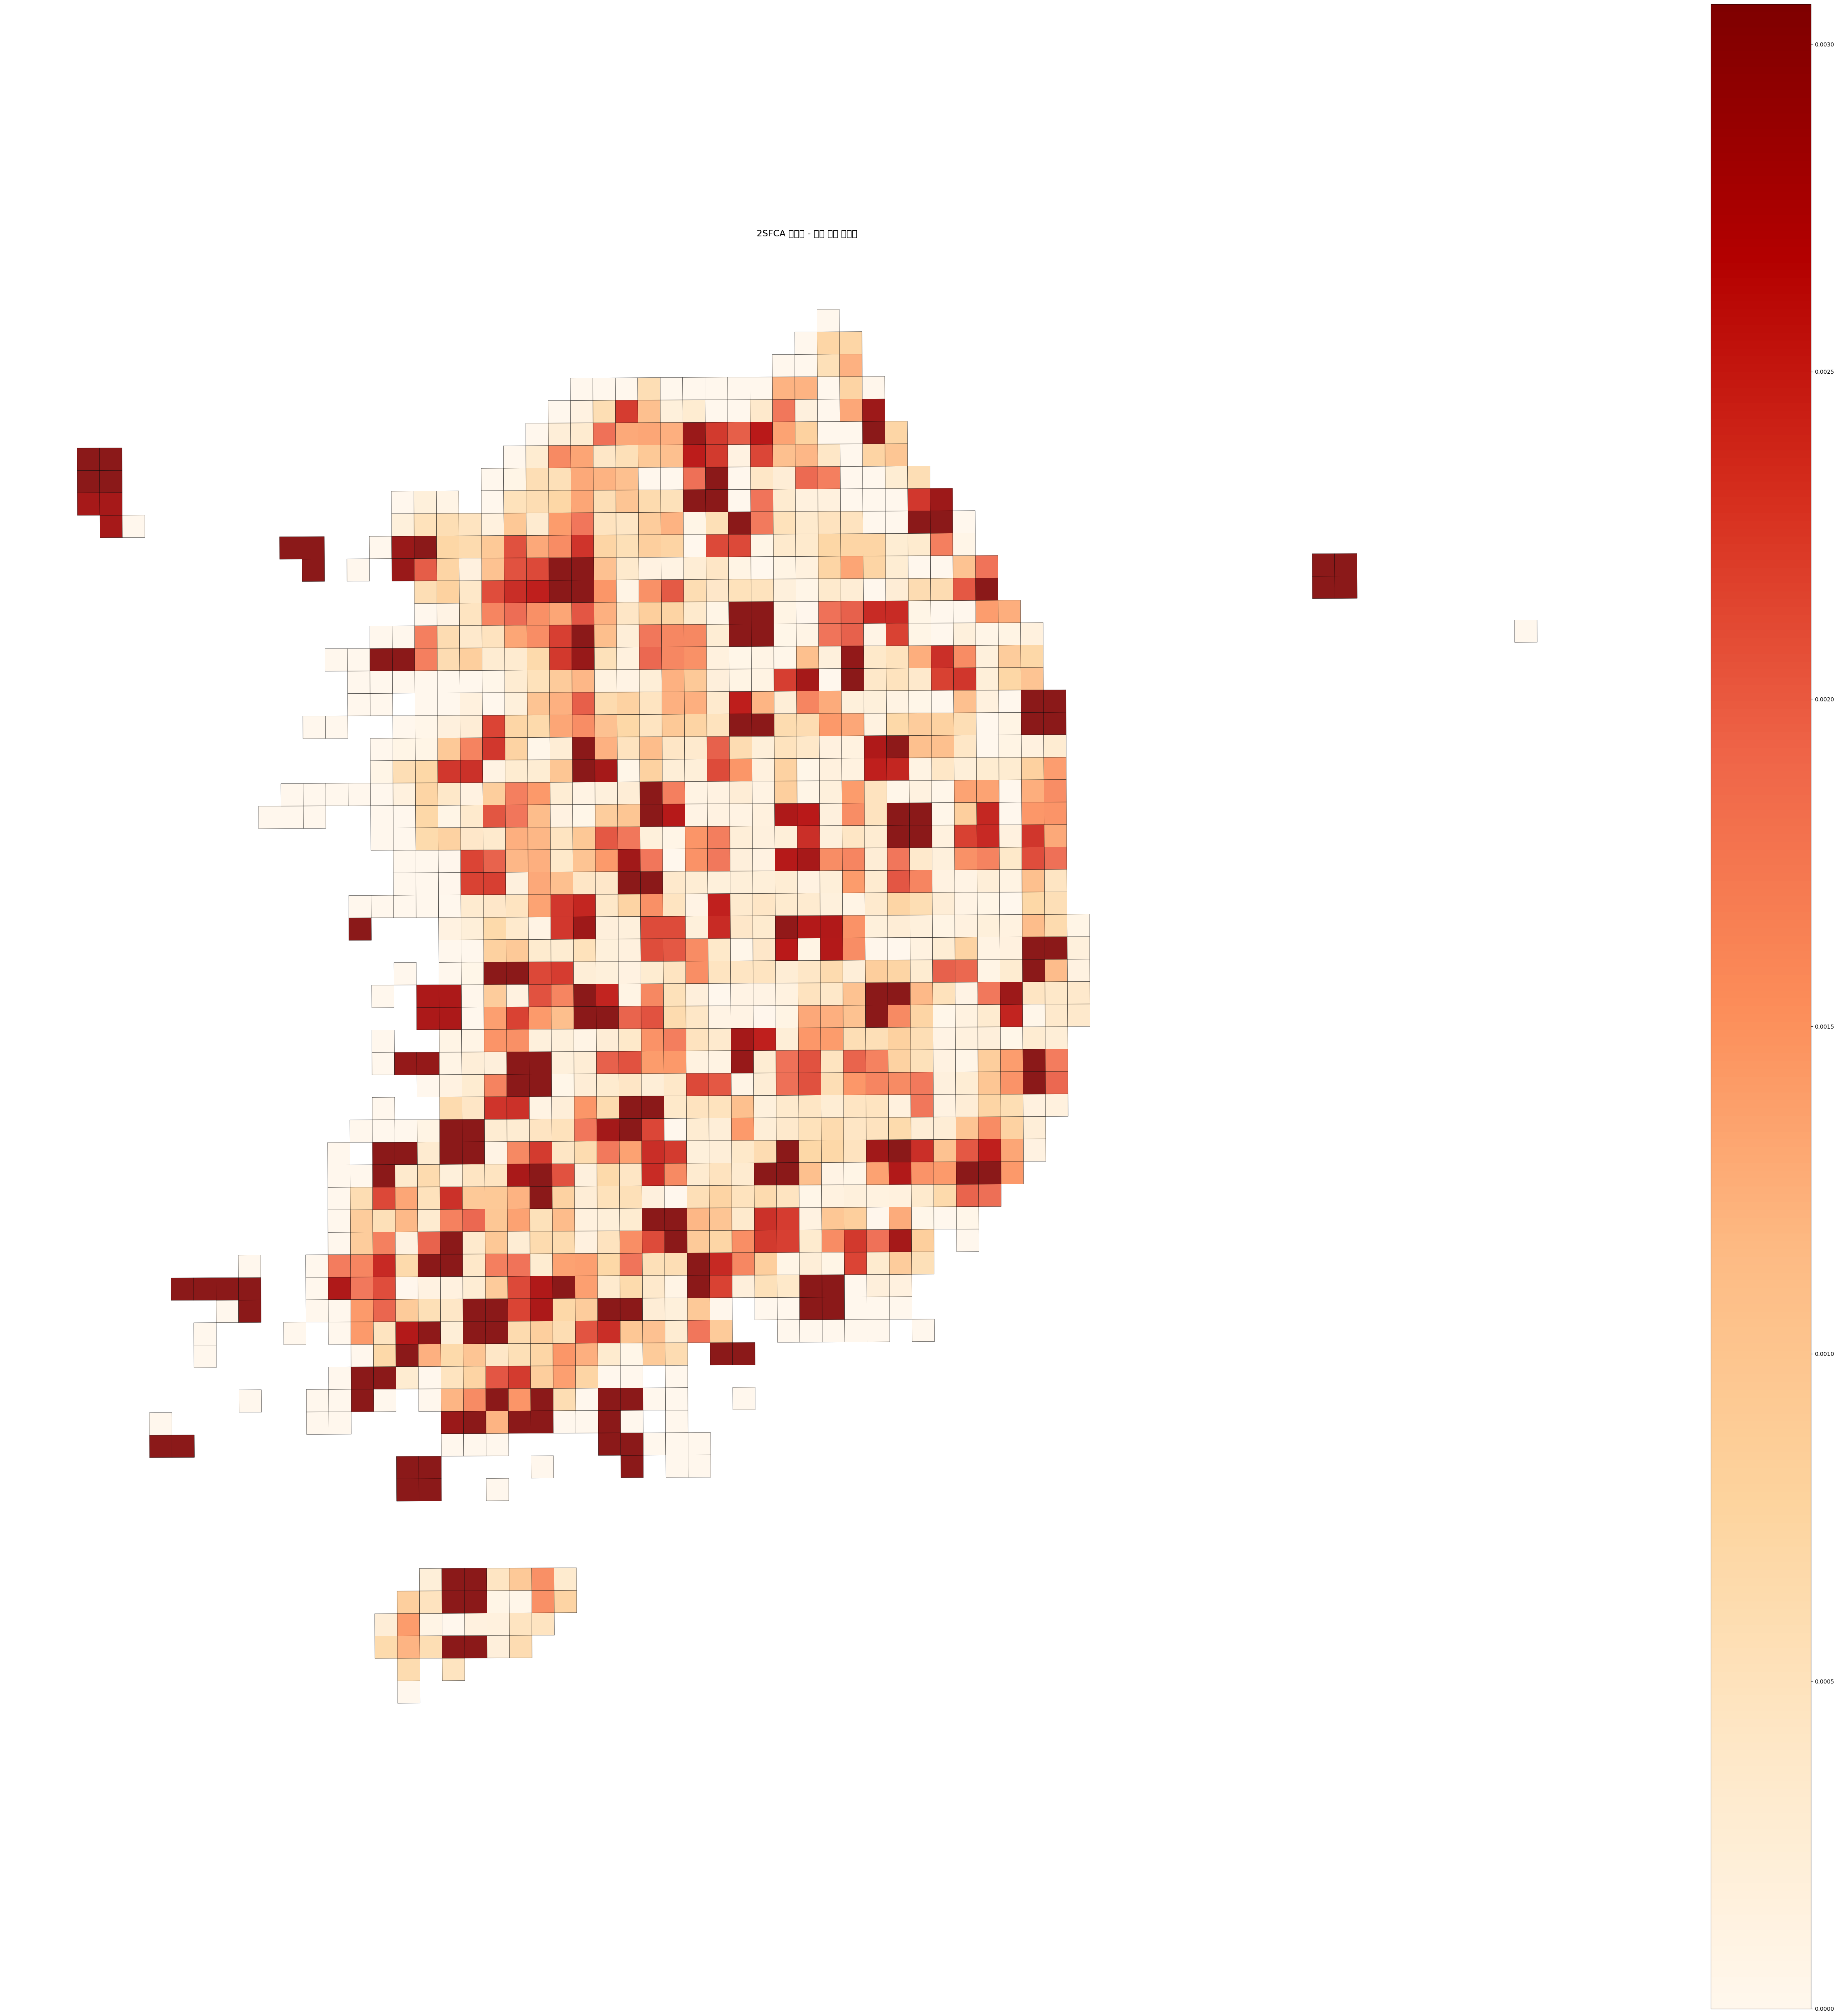

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
gdf = gpd.read_file("grid_with_accessibility_10K.gpkg")

# 2. figure 사이즈 키우기
fig, ax = plt.subplots(1, 1, figsize=(50, 50))  # 가로x세로 (inch)

# 3. 이상값 제한 (optional)
vmin = gdf["accessibility_index"].quantile(0.05)
vmax = gdf["accessibility_index"].quantile(0.9)


gdf.plot(
    column="accessibility_index",
    cmap="OrRd",
    legend=True,
    linewidth=0.4,
    edgecolor="black",  # 경계선 강조
    alpha=0.9,           # 불투명하게
    ax=ax,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("2SFCA 접근성 - 격자 기반 시각화", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import geopandas as gpd
import pandas as pd

# 1. 데이터 불러오기
gdf_grid = gpd.read_file("grid_with_accessibility_10K.gpkg")

sig_gdf = gpd.read_file("sig.shp", encoding="cp949")
sig_gdf.set_crs("EPSG:5179", inplace=True)
sig_gdf = sig_gdf.to_crs(gdf_grid.crs)

# 2. 시도코드 → 시도명 매핑
sido_dict = {
    "11": "서울특별시",
    "26": "부산광역시",
    "27": "대구광역시",
    "28": "인천광역시",
    "29": "광주광역시",
    "30": "대전광역시",
    "31": "울산광역시",
    "36": "세종특별자치시",
    "41": "경기도",
    "42": "강원특별자치도",
    "43": "충청북도",
    "44": "충청남도",
    "45": "전라북도",
    "46": "전라남도",
    "47": "경상북도",
    "48": "경상남도",
    "50": "제주특별자치도"
}

sig_gdf["SIDO_CODE"] = sig_gdf["SIG_CD"].str[:2]
sig_gdf["시도명"] = sig_gdf["SIDO_CODE"].map(sido_dict)

# 3. 광역시·특수시 제거 (서울, 부산, 대구, 인천, 광주, 대전, 울산, 세종)
exclude_codes = ["11","26","27","28","29","30","31"]
sig_gdf = sig_gdf[~sig_gdf["SIDO_CODE"].isin(exclude_codes)]

# 4. "구"를 "시"로 통합하기
# SIG_CD 앞 5자리가 같은 시를 의미함 (예: 고양시 덕양구, 일산동구, 일산서구 → 동일한 5자리 코드)
sig_gdf["SIG5"] = sig_gdf["SIG_CD"].str[:5]

# dissolve로 구 단위를 통합하여 시 단위/군 단위만 남김
sig_gdf_grouped = sig_gdf.dissolve(by=["SIDO_CODE", "SIG5", "시도명"], as_index=False)

# 이름 정리: "고양시 덕양구" → "고양시"
sig_gdf_grouped["SIG_KOR_NM"] = sig_gdf_grouped["SIG_KOR_NM"].str.replace(r"\s.+구$", "", regex=True)

# 5. 격자와 공간조인
joined = gpd.sjoin(gdf_grid, sig_gdf_grouped, how="left", predicate="intersects")

# NaN 제거
joined = joined.dropna(subset=["SIG_KOR_NM"])

# 6. 평균 접근성 계산 (시·군 단위)
sig_mean = joined.groupby(["시도명", "SIG_KOR_NM"])["accessibility_index"].mean().reset_index()

# 7. 최종 지역명 만들기
sig_mean["지역명"] = sig_mean["시도명"] + " " + sig_mean["SIG_KOR_NM"]
sig_mean.loc[sig_mean["시도명"] == "세종특별자치시", "지역명"] = "세종특별자치시"
final_result = sig_mean[["지역명", "accessibility_index"]].rename(columns={"accessibility_index":"평균접근성"})

# 8. 저장
final_result.to_csv("최종_지역별_접근성(광역시제외_구통합).csv", index=False, encoding="utf-8-sig")
print(final_result.head(30))


Empty GeoDataFrame
Columns: [GRID_10K_C, elderly_pop, accessibility_index, geometry, index_right, SIDO_CODE, SIG5, 시도명, SIG_CD, SIG_ENG_NM, SIG_KOR_NM]
Index: []


In [1]:
import geopandas as gpd
import pandas as pd

# 1. 데이터 불러오기
gdf_grid = gpd.read_file("grid_with_accessibility_10K.gpkg")

sig_gdf = gpd.read_file("sig.shp", encoding="cp949")
sig_gdf.set_crs("EPSG:5179", inplace=True)
sig_gdf = sig_gdf.to_crs(gdf_grid.crs)

# 2. 시도코드 → 시도명 매핑
sido_dict = {
    "11": "서울특별시",
    "26": "부산광역시",
    "27": "대구광역시",
    "28": "인천광역시",
    "29": "광주광역시",
    "30": "대전광역시",
    "31": "울산광역시",
    "36": "세종특별자치시",
    "41": "경기도",
    "51": "강원특별자치도",
    "43": "충청북도",
    "44": "충청남도",
    "45": "전라북도",
    "46": "전라남도",
    "47": "경상북도",
    "48": "경상남도",
    "50": "제주특별자치도"
}

sig_gdf["SIDO_CODE"] = sig_gdf["SIG_CD"].str[:2]
sig_gdf["시도명"] = sig_gdf["SIDO_CODE"].map(sido_dict)

# 3. 광역시·특수시 제거 (서울, 부산, 대구, 인천, 광주, 대전, 울산, 세종)
exclude_codes = ["11","26","27","28","29","30","31"]
sig_gdf = sig_gdf[~sig_gdf["SIDO_CODE"].isin(exclude_codes)]

# 4. "구"를 "시"로 통합하기
# SIG_CD 앞 5자리가 같은 시를 의미함 (예: 고양시 덕양구, 일산동구, 일산서구 → 동일한 5자리 코드)
sig_gdf["SIG5"] = sig_gdf["SIG_CD"].str[:5]

# dissolve로 구 단위를 통합하여 시 단위/군 단위만 남김
sig_gdf_grouped = sig_gdf.dissolve(by=["SIDO_CODE", "SIG5", "시도명"], as_index=False)

# 이름 정리: "고양시 덕양구" → "고양시"
sig_gdf_grouped["SIG_KOR_NM"] = sig_gdf_grouped["SIG_KOR_NM"].str.replace(r"\s.+구$", "", regex=True)

# 5. 격자와 공간조인
joined = gpd.sjoin(gdf_grid, sig_gdf_grouped, how="left", predicate="intersects")

# NaN 디버깅
print("NaN 지역 샘플:")
print(joined[joined["SIG_KOR_NM"].isna()])

# NaN 제거
joined = joined.dropna(subset=["SIG_KOR_NM"])

# 6. 평균 접근성 계산 (시·군 단위)
sig_mean = joined.groupby(["시도명", "SIG_KOR_NM"])["accessibility_index"].mean().reset_index()

# 7. 최종 지역명 만들기
sig_mean["지역명"] = sig_mean["시도명"] + " " + sig_mean["SIG_KOR_NM"]
sig_mean.loc[sig_mean["시도명"] == "세종특별자치시", "지역명"] = "세종특별자치시"
final_result = sig_mean[["지역명", "accessibility_index"]].rename(columns={"accessibility_index":"평균접근성"})

NaN 지역 샘플:
     GRID_10K_C  elderly_pop  accessibility_index  \
7          가사57           78             0.002835   
8          가사67            0             0.000000   
9          가사48            0             0.002835   
10         가사58          447             0.002835   
11         가사49          148             0.004785   
...         ...          ...                  ...   
1161       마마53        27781             0.001491   
1162       마마63       134728             0.003361   
1163       마마73         7328             0.001827   
1208       마마09         1802             0.000287   
1232       마바71            0             0.000489   

                                               geometry  index_right  \
7     POLYGON ((-5991.382 468770.083, -6044.874 4787...          NaN   
8     POLYGON ((4010.055 468823.52, 3956.565 478825....          NaN   
9     POLYGON ((-16046.204 478717.92, -16099.807 488...          NaN   
10    POLYGON ((-6044.874 478771.467, -6098.474 4887...         

In [2]:
import geopandas as gpd
import pandas as pd
from pyproj import CRS

# ----------------------------
# 0) 데이터 경로
# ----------------------------
GPKG = "grid_with_accessibility_10K.gpkg"
GPKG_LAYER = "grid_with_accessibility_10K"
SIG_SHP = "sig.shp"

# 안전 로더
def safe_read(path, **kwargs):
    try:
        return gpd.read_file(path, engine="pyogrio", **kwargs)
    except Exception:
        return gpd.read_file(path, **kwargs)

# ----------------------------
# 1) 데이터 로드
# ----------------------------
print("[Step 1] 데이터 로드")
gdf_grid = safe_read(GPKG, layer=GPKG_LAYER)
sig_gdf = gpd.read_file(SIG_SHP, encoding="cp949")

print("  - grid crs:", gdf_grid.crs)
print("  - sig  crs:", sig_gdf.crs)

if sig_gdf.crs is None:
    print("  ! sig.shp 에 CRS 정보가 없어 EPSG:5179로 지정")
    sig_gdf = sig_gdf.set_crs("EPSG:5179")

if CRS.from_user_input(sig_gdf.crs) != CRS.from_user_input(gdf_grid.crs):
    print("  - 좌표계가 달라 변환합니다")
    sig_gdf = sig_gdf.to_crs(gdf_grid.crs)

# ----------------------------
# 2) 시도 코드 생성 및 매핑
# ----------------------------
sig_gdf["SIDO_CODE"] = sig_gdf["SIG_CD"].astype(str).str[:2]

sido_dict = {
    "11": "서울특별시",
    "26": "부산광역시",
    "27": "대구광역시",
    "28": "인천광역시",
    "29": "광주광역시",
    "30": "대전광역시",
    "31": "울산광역시",
    "36": "세종특별자치시",
    "41": "경기도",
    "43": "충청북도",
    "44": "충청남도",
    "45": "전라북도",
    "46": "전라남도",
    "47": "경상북도",
    "48": "경상남도",
    "50": "제주특별자치도",
    "51": "강원특별자치도"   # ✅ 강원 코드 수정
}
sig_gdf["시도명"] = sig_gdf["SIDO_CODE"].map(sido_dict)

print("[Step 2] 시도 코드 분포")
print(sig_gdf["SIDO_CODE"].value_counts().sort_index())

# ----------------------------
# 3) 광역시/특수시 제외
# ----------------------------
exclude_codes = ["11","26","27","28","29","30","31","36"]
sig_gdf = sig_gdf[~sig_gdf["SIDO_CODE"].isin(exclude_codes)].copy()

print("[Step 3] 제외 후 시도 코드 분포")
print(sig_gdf["SIDO_CODE"].value_counts().sort_index())

# ----------------------------
# 4) 구 → 시 통합
# ----------------------------
sig_gdf["CITY_CODE"] = (sig_gdf["SIG_CD"].astype(int) // 10) * 10
sig_gdf["CITY_CODE"] = sig_gdf["CITY_CODE"].astype(str).str.zfill(5)

sig_grouped = sig_gdf.dissolve(
    by=["SIDO_CODE","CITY_CODE","시도명"],
    as_index=False, aggfunc="first"
)

if "SIG_KOR_NM" in sig_grouped.columns:
    sig_grouped["SIG_KOR_NM"] = sig_grouped["SIG_KOR_NM"].str.replace(r"\s.+구$", "", regex=True)

print("[Step 4] 통합 후 행정구역 수:", len(sig_grouped))

# ----------------------------
# 5) 공간조인 (격자 중심점 기준)
# ----------------------------
gdf_grid_cent = gdf_grid.copy()
gdf_grid_cent["geometry"] = gdf_grid_cent.geometry.centroid

joined = gpd.sjoin(gdf_grid_cent, sig_grouped, how="left", predicate="within")

print("[Step 5] 조인 후 NaN 비율:", joined["시도명"].isna().mean())
print("  - 강원 매칭 그리드 수:", len(joined[joined["시도명"]=="강원특별자치도"]))

# ----------------------------
# 6) 집계 및 저장
# ----------------------------
sig_mean = joined.groupby(["시도명","SIG_KOR_NM"], dropna=False)["accessibility_index"].mean().reset_index()
sig_mean["지역명"] = sig_mean["시도명"] + " " + sig_mean["SIG_KOR_NM"]
sig_mean.loc[sig_mean["시도명"]=="세종특별자치시","지역명"] = "세종특별자치시"

final = sig_mean[["지역명","accessibility_index"]].rename(columns={"accessibility_index":"평균접근성"})
final.to_csv("최종_지역별_접근성(광역시제외_구통합)_디버그출력.csv", index=False, encoding="utf-8-sig")
print("  - 저장 완료: 최종_지역별_접근성(광역시제외_구통합)_디버그출력.csv")


[Step 1] 데이터 로드
  - grid crs: EPSG:5181
  - sig  crs: None
  ! sig.shp 에 CRS 정보가 없어 EPSG:5179로 지정
  - 좌표계가 달라 변환합니다
[Step 2] 시도 코드 분포
SIDO_CODE
11    25
26    16
27     9
28    10
29     5
30     5
31     5
36     1
41    42
43    14
44    16
45    15
46    22
47    23
48    22
50     2
51    18
Name: count, dtype: int64
[Step 3] 제외 후 시도 코드 분포
SIDO_CODE
41    42
43    14
44    16
45    15
46    22
47    23
48    22
50     2
51    18
Name: count, dtype: int64
[Step 4] 통합 후 행정구역 수: 152
[Step 5] 조인 후 NaN 비율: 0.3047970479704797
  - 강원 매칭 그리드 수: 168
  - 저장 완료: 최종_지역별_접근성(광역시제외_구통합)_디버그출력.csv


In [19]:
import geopandas as gpd
import pandas as pd
from pyproj import CRS

# ----------------------------
# 0) 데이터 경로
# ----------------------------
GPKG = "grid_with_accessibility_1K.gpkg"   # 또는 10K 파일
GPKG_LAYER = "grid_with_accessibility_1K"  # 레이어명에 맞게
SIG_SHP = "sig.shp"

def safe_read(path, **kwargs):
    try:
        return gpd.read_file(path, engine="pyogrio", **kwargs)
    except Exception:
        return gpd.read_file(path, **kwargs)

# ----------------------------
# 1) 데이터 로드 & 좌표계 통일
# ----------------------------
grid = safe_read(GPKG, layer=GPKG_LAYER)
sig  = gpd.read_file(SIG_SHP, encoding="cp949")

if sig.crs is None:
    sig = sig.set_crs("EPSG:5179")  # sig.shp 원본이 5179인 경우가 많음

if CRS.from_user_input(sig.crs) != CRS.from_user_input(grid.crs):
    sig = sig.to_crs(grid.crs)

# ----------------------------
# 2) 시도 코드 & 이름
# ----------------------------
sig["SIDO_CODE"] = sig["SIG_CD"].astype(str).str[:2]
sido_dict = {
    "11":"서울특별시","26":"부산광역시","27":"대구광역시","28":"인천광역시",
    "29":"광주광역시","30":"대전광역시","31":"울산광역시","36":"세종특별자치시",
    "41":"경기도","43":"충청북도","44":"충청남도","45":"전라북도",
    "46":"전라남도","47":"경상북도","48":"경상남도","50":"제주특별자치도",
    "51":"강원특별자치도"
}
sig["시도명"] = sig["SIDO_CODE"].map(sido_dict)

# ----------------------------
# 3) (선택) 광역시/특별시 제외
# ----------------------------
exclude_codes = ["11","26","27","28","29","30","31"]
sig = sig[~sig["SIDO_CODE"].isin(exclude_codes)].copy()

# ----------------------------
# 4) '구' 통합 대신 '첫 단어' 기반의 시/군 레벨 이름 생성
#    예) '창원시 마산회원구' -> '창원시'
#        '청도군' -> '청도군' (그대로)
#        '세종특별자치시' -> '세종특별자치시'
# ----------------------------
sig["CITY_NAME"] = sig["SIG_KOR_NM"].str.split().str[0]

# 시/군 레벨로 dissolve (코드 기반으로도 묶어주면 더 안전)
sig["CITY_CODE"] = (sig["SIG_CD"].astype(int) // 10) * 10
sig["CITY_CODE"] = sig["CITY_CODE"].astype(str).str.zfill(5)

sig_city = sig.dissolve(
    by=["SIDO_CODE","CITY_CODE","시도명","CITY_NAME"],
    as_index=False, aggfunc="first"
)

# ----------------------------
# 5) 공간조인 (격자 중심점 기준)
# ----------------------------
grid_cent = grid.copy()
grid_cent["geometry"] = grid_cent.geometry.centroid

joined = gpd.sjoin(grid_cent, sig_city, how="left", predicate="within")

# ----------------------------
# 6) 집계 & 저장
# ----------------------------
out = (
    joined
    .groupby(["시도명","CITY_NAME"], dropna=False)["accessibility_index"]
    .mean()
    .reset_index()
)

# 지역명 생성: 세종이면 시도명만, 나머지는 시도명+시군명
def make_region_name(row):
    if pd.isna(row["시도명"]) or pd.isna(row["CITY_NAME"]):
        return None
    if row["시도명"] == "세종특별자치시":
        return "세종특별자치시"   # 시군명 없이 통일
    return f"{row['시도명']} {row['CITY_NAME']}"

out["지역명"] = out.apply(make_region_name, axis=1)
out = out.rename(columns={"accessibility_index":"평균접근성"})[
    ["지역명","평균접근성"]
]

# NaN 지역 제거
out = out.dropna(subset=["지역명"])

# 저장
out.to_csv("최종_지역별_접근성(세종수정_구통합)_v3.csv", index=False, encoding="utf-8-sig")
print("저장 완료:", len(out), "개 지역")

저장 완료: 154 개 지역


In [10]:
import geopandas as gpd

sig_gdf = gpd.read_file("sig.shp", encoding="cp949")

# 고유 코드 목록 확인
print(sig_gdf["SIG_CD"].unique())

# 세종 코드(36***로 시작)가 있는지 체크
print(sig_gdf[sig_gdf["SIG_CD"].str.startswith("36")])


['11110' '11140' '11170' '11200' '11215' '11230' '11260' '11290' '11305'
 '11320' '11350' '11380' '11410' '11440' '11470' '11500' '11530' '11545'
 '11560' '11590' '11620' '11650' '11680' '11710' '11740' '26110' '26140'
 '26170' '26200' '26230' '26260' '26290' '26320' '26350' '26380' '26410'
 '26440' '26470' '26500' '26530' '26710' '27110' '27140' '27170' '27200'
 '27230' '27260' '27290' '27710' '27720' '28110' '28140' '28177' '28185'
 '28200' '28237' '28245' '28260' '28710' '28720' '29110' '29140' '29155'
 '29170' '29200' '30110' '30140' '30170' '30200' '30230' '31110' '31140'
 '31170' '31200' '31710' '36110' '41111' '41113' '41115' '41117' '41131'
 '41133' '41135' '41150' '41171' '41173' '41190' '41210' '41220' '41250'
 '41271' '41273' '41281' '41285' '41287' '41290' '41310' '41360' '41370'
 '41390' '41410' '41430' '41450' '41461' '41463' '41465' '41480' '41500'
 '41550' '41570' '41590' '41610' '41630' '41650' '41670' '41800' '41820'
 '41830' '43111' '43112' '43113' '43114' '43130' '4

In [21]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv("최종_지역별_접근성(세종수정_구통합)_v3.csv")

# 2. 평균과 표준편차 계산
mean_val = df["평균접근성"].mean()
std_val = df["평균접근성"].std()
print(mean_val)

# 3. 등급 구분 함수 정의
def classify_accessibility(value):
    if value >= mean_val + 0.5 * std_val:
        return 3  # 상
    elif value <= mean_val - 0.5 * std_val:
        return 1  # 하
    else:
        return 2  # 중

# 4. 등급 컬럼 추가
df["접근성등급(1:하,2:중,3:상)"] = df["평균접근성"].apply(classify_accessibility)

# 5. 결과 확인
print(df.head())
print(df["접근성등급(1:하,2:중,3:상)"].value_counts())

# 6. 저장
df.to_csv("시군구별_접근성_평균_등급포함.csv", index=False, encoding="utf-8-sig")


0.002239020919597862
           지역명     평균접근성  접근성등급(1:하,2:중,3:상)
0  강원특별자치도 강릉시  0.001654                   1
1  강원특별자치도 고성군  0.000881                   1
2  강원특별자치도 동해시  0.002303                   2
3  강원특별자치도 삼척시  0.000881                   1
4  강원특별자치도 속초시  0.002200                   2
접근성등급(1:하,2:중,3:상)
2    69
1    52
3    33
Name: count, dtype: int64


In [22]:
# 전체 격자의 접근성 지표 평균 계산
average_accessibility = gdf_grid["accessibility_index"].mean()
print(f"전체 격자의 평균 접근성 지표: {average_accessibility}")

전체 격자의 평균 접근성 지표: 0.0020393682330821557


c:\Users\Playdata\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Playdata\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Playdata\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Playdata\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Playdata\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  fig.canv

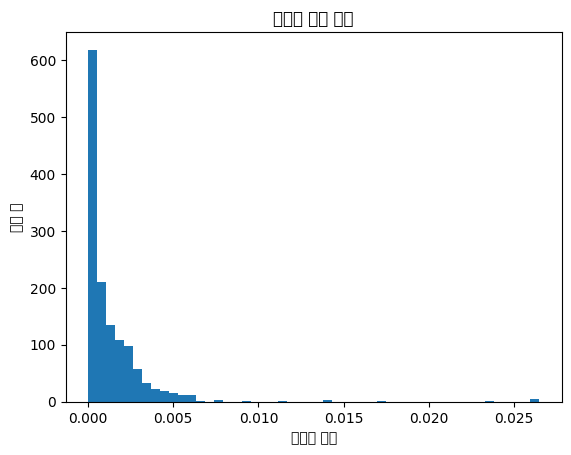

In [4]:
import matplotlib.pyplot as plt

gdf_grid["accessibility_index"].plot(kind='hist', bins=50)
plt.title("접근성 지표 분포")
plt.xlabel("접근성 점수")
plt.ylabel("격자 수")
plt.show()

In [6]:
# 상위 10%, 하위 10% 경계값 계산
top_10 = gdf_grid["accessibility_index"].quantile(0.9)
bottom_10 = gdf_grid["accessibility_index"].quantile(0.5)

print(f"상위 10% 경계: {top_10}, 하위 50% 경계: {bottom_10}")

상위 10% 경계: 0.003061341782633348, 하위 50% 경계: 0.0006298296314146807


In [7]:
!pip install contextily

In [8]:
!pip install mapclassify

In [9]:
print(sig_gdf.columns)

Index(['SIG_CD', 'SIG_ENG_NM', 'SIG_KOR_NM', 'geometry'], dtype='object')


광역시별 평균 접근성 지표:
SIG_KOR_NM
춘천시    0.000021
문경시    0.000089
울진군    0.000117
거창군    0.000123
함양군    0.000134
         ...   
영광군    0.003518
남원시    0.003641
제주시    0.004381
진주시    0.004455
원주시    0.004816
Name: accessibility_index, Length: 74, dtype: float64


C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\1269272166.py:20: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\1269272166.py:20: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\1269272166.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\1269272166.py:20: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\1269272166.py:20: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_31048\1269272166.py:20: UserWarning: Glyph 50872 (\N{HANGUL SYLLA

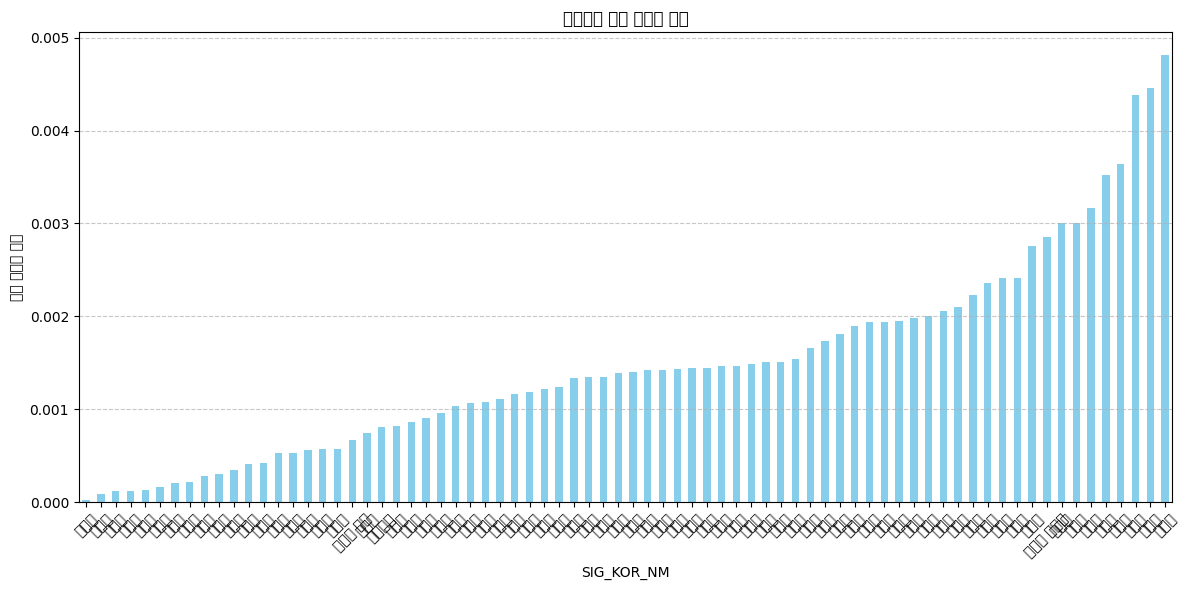

In [5]:
import geopandas as gpd  # GeoPandas 임포트 추가
import matplotlib.pyplot as plt

# 광역시 경계 데이터와 공간 조인 수행
gdf_grid_with_sido = gpd.sjoin(gdf_grid, sig_gdf[['SIG_KOR_NM', 'geometry']], how='left', predicate='within')

# 광역시별 접근성 지표 평균 계산
sido_avg = gdf_grid_with_sido.groupby('SIG_KOR_NM')['accessibility_index'].mean().sort_values()

print("광역시별 평균 접근성 지표:")
print(sido_avg)

# 광역시별 평균을 막대 그래프로 시각화
plt.figure(figsize=(12, 6))
sido_avg.plot(kind='bar', color='skyblue')
plt.title('광역시별 평균 접근성 지표')
plt.ylabel('평균 접근성 점수')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
print(sig_gdf.columns)

Index(['SIG_CD', 'SIG_ENG_NM', 'SIG_KOR_NM', 'geometry'], dtype='object')


In [ ]:
import geopandas as gpd

# 1. 파일 불러오기
gdf_grid_with_sido = gpd.read_file("grid_with_accessibility_10K.gpkg")
sig_gdf = gpd.read_file("sig.shp", encoding="cp949")  # 시군구 경계 데이터

# 2. 좌표계 통일
sig_gdf = sig_gdf.set_crs("EPSG:5179")
sig_gdf = sig_gdf.to_crs(gdf_grid_with_sido.crs)

# 3. Spatial Join으로 시군구 이름 붙이기
gdf_grid_with_sido = gpd.sjoin(gdf_grid_with_sido, sig_gdf[['SIG_CD', 'SIG_KOR_NM', 'geometry']], how='left', predicate='intersects')

# 4. 시도 코드 앞 두 자리 → 시도명 매핑
sido_code_map = {
    "26": "부산광역시", "27": "대구광역시", "28": "인천광역시", "29": "광주광역시",
    "30": "대전광역시", "31": "울산광역시", "36": "세종특별자치시", "41": "경기도", "42": "강원도",
    "43": "충청북도", "44": "충청남도", "45": "전라북도", "46": "전라남도", "47": "경상북도",
    "48": "경상남도", "50": "제주특별자치도"
}

# 5. 시도명 컬럼 생성
gdf_grid_with_sido["CTP_KOR_NM"] = gdf_grid_with_sido["SIG_CD"].str[:2].map(sido_code_map)

# 6. 시도 + 시군구 결합
gdf_grid_with_sido["시도_시군구"] = gdf_grid_with_sido["CTP_KOR_NM"] + " " + gdf_grid_with_sido["SIG_KOR_NM"]

# 7. 평균 접근성 계산
sido_sig_avg = gdf_grid_with_sido.groupby("시도_시군구")["accessibility_index"].mean().reset_index()
sido_sig_avg.columns = ["지역명", "평균접근성지표"]

# 8. 저장
sido_sig_avg.to_csv("시군구_단위_평균접근성지표.csv", index=False, encoding="utf-8-sig")

# 확인
print(sido_sig_avg.head())
print(f"총 지역 수: {len(sido_sig_avg)}")


            지역명   평균접근성지표
0       경기도 가평군  0.000981
1   경기도 고양시 덕양구  0.001905
2  경기도 고양시 일산동구  0.001428
3  경기도 고양시 일산서구  0.001614
4       경기도 과천시  0.003026
총 지역 수: 232


In [11]:
# Series를 DataFrame으로 변환
sido_avg_df = sido_avg.reset_index()

# 컬럼 이름 설정 (선택)
sido_avg_df.columns = ['시도명', '평균접근성지표']

# CSV로 저장
sido_avg_df.to_csv("광역시별_평균접근성지표.csv", index=False, encoding='utf-8-sig')


In [11]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv("시군구별_접근성_평균.csv")

# 2. 평균과 표준편차 계산
mean_val = df["평균접근성지표"].mean()
std_val = df["평균접근성지표"].std()

# 3. 등급 구분 함수 정의
def classify_accessibility(value):
    if value >= mean_val + 0.5 * std_val:
        return 1  # 상
    elif value <= mean_val - 0.5 * std_val:
        return 3  # 하
    else:
        return 2  # 중

# 4. 등급 컬럼 추가
df["접근성등급(1:상,2:중,3:하)"] = df["평균접근성지표"].apply(classify_accessibility)

# 5. 결과 확인
print(df.head())
print(df["접근성등급(1:상,2:중,3:하)"].value_counts())

# 6. 저장
df.to_csv("시군구별_접근성_평균_등급포함.csv", index=False, encoding="utf-8-sig")


KeyError: '평균접근성지표'

In [12]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv("광역시별_평균접근성지표.csv")

# 분위수 기준 구간 구하기
q_low = df['평균접근성지표'].quantile(1/3)
q_high = df['평균접근성지표'].quantile(2/3)

# 분류 함수 정의
def classify_accessibility(value):
    if value <= q_low:
        return '하'
    elif value <= q_high:
        return '중'
    else:
        return '상'

# 새로운 컬럼 추가
df['접근성_등급'] = df['평균접근성지표'].apply(classify_accessibility)

# 결과 확인
print(df.head())

# 저장
df.to_csv("시군구별_접근성_등급_분류.csv", index=False)

   시도명   평균접근성지표 접근성_등급
0  춘천시  0.000021      하
1  문경시  0.000089      하
2  울진군  0.000117      하
3  거창군  0.000123      하
4  함양군  0.000134      하


c:\Users\Playdata\miniconda3\Lib\site-packages\geopandas\plotting.py:955: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\Playdata\miniconda3\Lib\site-packages\geopandas\plotting.py:955: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\Playdata\miniconda3\Lib\site-packages\geopandas\plotting.py:955: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\Playdata\miniconda3\Lib\site-packages\geopandas\plotting.py:955: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\Playdata\miniconda3\Lib\site-packages\geopandas\plotting.py:955: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\Playdata\miniconda3\Lib\site-packages\

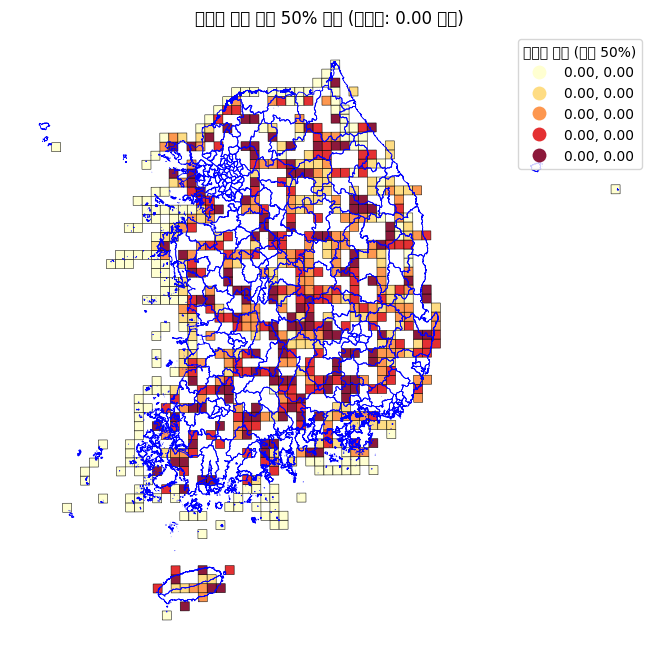


하위 50% 격자 통계 정보:
count    677.000000
mean       0.000215
std        0.000190
min        0.000000
25%        0.000019
50%        0.000183
75%        0.000362
max        0.000629
Name: accessibility_index, dtype: float64


In [ ]:
# 전체 데이터에서 하위 50% 경계값 계산
median_value = gdf_grid["accessibility_index"].quantile(0.5)

# 하위 50% 격자 필터링
bottom_50 = gdf_grid[gdf_grid["accessibility_index"] <= median_value]

# 지도 시각화
fig, ax = plt.subplots(figsize=(12, 8))

# 하위 50% 격자 표시
bottom_50.plot(
    column="accessibility_index",
    cmap="YlOrRd",
    legend=True,
    linewidth=0.4,
    edgecolor="black",
    alpha=0.9,
    ax=ax,
    scheme='quantiles',
    legend_kwds={'title': "접근성 지표 (하위 50%)"}
)

# 광역시 경계선 덧그리기
sig_gdf.boundary.plot(ax=ax, color="blue", linewidth=0.6)

# 시도 이름 라벨링
# for idx, row in sig_gdf.iterrows():
#     ax.text(row["center"].x, row["center"].y, row["SIG_KOR_NM"], fontsize=10, ha='center')

plt.title(f"접근성 지표 하위 50% 지역 (중앙값: {median_value:.2f} 이하)")
plt.axis('off')
plt.show()

# 하위 50% 격자 통계 정보 출력
print("\n하위 50% 격자 통계 정보:")
print(bottom_50["accessibility_index"].describe())

In [ ]:
import geopandas as gpd
import pandas as pd

# 전국 기준 하위 50% 경계값 계산 (중앙값)
national_median = gdf_grid["accessibility_index"].quantile(0.5)

# 하위 50% 격자 필터링
bottom_50_national = gdf_grid[gdf_grid["accessibility_index"] <= national_median]

# 광역시도별 하위 50% 격자 수 집계
sido_bottom_50_count = (
    gpd.sjoin(bottom_50_national, gdf_sido, how="left", predicate="within")
    .groupby("CTP_KOR_NM")
    .size()
    .reset_index(name="count_bottom_50")
)

# 광역시도별 전체 격자 수 계산
total_count_by_sido = (
    gpd.sjoin(gdf_grid, gdf_sido, how="left", predicate="within")
    .groupby("CTP_KOR_NM")
    .size()
    .reset_index(name="total_count")
)

# 결과 통합 (하위 50% 비율 추가)
sido_stats = pd.merge(
    total_count_by_sido,
    sido_bottom_50_count,
    on="CTP_KOR_NM",
    how="left"
).fillna(0)  # NaN인 경우 0으로 처리 (하위 50% 격자가 없는 경우)

sido_stats["ratio"] = sido_stats["count_bottom_50"] / sido_stats["total_count"]
print(sido_stats.sort_values("ratio", ascending=False))

  CTP_KOR_NM  total_count  count_bottom_50     ratio
6    제주특별자치도            8              6.0  0.750000
2       경상북도          140             83.0  0.592857
0        강원도          121             69.0  0.570248
7       충청북도           45             18.0  0.400000
1        경기도           66             22.0  0.333333
3      광주광역시            2              0.0  0.000000
5      울산광역시            3              0.0  0.000000
4      대구광역시            1              0.0  0.000000


In [56]:
print(gdf_grid_with_sido["CTP_KOR_NM"].isna().sum())  # 공간 조인 실패한 격자 수

968


In [65]:
# 1. 좌표계 통일
gdf_sido = gdf_sido.to_crs(gdf_grid.crs)

# 2. 공간 조인 (조건 완화)
gdf_joined = gpd.sjoin(gdf_grid, gdf_sido, how="left", predicate="intersects")

# 3. 실패한 격자 처리 (최근접 이웃 매칭)
failed = gdf_joined[gdf_joined["CTP_KOR_NM"].isna()].copy()
if not failed.empty:
    for idx, row in failed.iterrows():
        nearest_sido = gdf_sido.geometry.distance(row.geometry).idxmin()
        gdf_joined.at[idx, "CTP_KOR_NM"] = gdf_sido.iloc[nearest_sido]["CTP_KOR_NM"]

# 4. 결과 확인
print(f"최종 실패 격자 수: {gdf_joined['CTP_KOR_NM'].isna().sum()}")

최종 실패 격자 수: 0


In [71]:
# 2. 전국 기준 하위 50% 경계값 (중앙값) 계산
national_median = gdf_grid["accessibility_index"].median()
print(f"전국 중앙값(하위 50% 기준): {national_median:.2f}")

# 3. 하위 50% 격자 필터링 및 지역별 집계
gdf_joined["is_bottom_50"] = gdf_joined["accessibility_index"] <= national_median

# 광역시도별 통계 계산
sido_stats = (
    gdf_joined.groupby("CTP_KOR_NM")
    .agg(
        total_grids=("accessibility_index", "size"),          # 전체 격자 수
        bottom_50_grids=("is_bottom_50", "sum"),             # 하위 50% 격자 수
        bottom_50_ratio=("is_bottom_50", "mean")             # 하위 50% 비율
    )
    .sort_values("bottom_50_grids", ascending=False)
    .reset_index()
)

# 4. 결과 출력 (표)
print("\n[지역별 하위 50% 격자 현황]")
print(sido_stats.round(2).sort_values("bottom_50_grids", ascending=False))

전국 중앙값(하위 50% 기준): 0.00

[지역별 하위 50% 격자 현황]
   CTP_KOR_NM  total_grids  bottom_50_grids  bottom_50_ratio
0        경상북도          247              144             0.58
1         강원도          207              116             0.56
2        전라남도          253              107             0.42
3        경상남도          158               85             0.54
4        충청북도          110               63             0.57
5         경기도          147               57             0.39
6        충청남도           81               55             0.68
7        전라북도           74               36             0.49
8       인천광역시           58               26             0.45
9     제주특별자치도           33               16             0.48
10      광주광역시           26               10             0.38
11    세종특별자치시           24               10             0.42
12      울산광역시           19                9             0.47
13      대구광역시           21                7             0.33
14      대전광역시           13               

In [73]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)


In [74]:
sido_stats.to_excel("지역별_하위50_격자_현황.xlsx", 
                   index=False, 
                   sheet_name="하위50_격자")
print("✅ 엑셀 파일 저장 완료: '지역별_하위50_격자_현황.xlsx'")

✅ 엑셀 파일 저장 완료: '지역별_하위50_격자_현황.xlsx'


In [75]:
# 표 데이터프레임 저장 (CSV)
sido_stats.to_csv("지역별_하위50_격자_현황.csv", 
                 index=False, 
                 encoding="utf-8-sig")  # 한글 깨짐 방지
print("✅ CSV 파일 저장 완료: '지역별_하위50_격자_현황.csv'")

✅ CSV 파일 저장 완료: '지역별_하위50_격자_현황.csv'


In [27]:
gdf.geom_type.value_counts()


Polygon    107661
Name: count, dtype: int64

In [1]:
import geopandas as gpd
import pandas as pd
import glob

# 1. 모든 txt 파일에서 고령 인구 데이터 만들기 (이전과 동일)
txt_files = glob.glob("./1km/txt_data/*.txt")
df_list = []

for file in txt_files:
    df = pd.read_csv(file, sep="\\^", header=None, engine="python")
    df.columns = ["year", "grid_id", "age_code", "count"]
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
df_all["age"] = df_all["age_code"].str.extract(r"in_age_(\d+)")[0].astype(float)
df_all = df_all.dropna(subset=["age"])
df_all["age"] = df_all["age"].astype(int)
df_elder = df_all[df_all["age"] >= 65]
df_elder_sum = df_elder.groupby("grid_id")["count"].sum().reset_index()
df_elder_sum.columns = ["GRID_1K_CD", "elderly_pop"]

# 2. 모든 grid_XX_10K.shp 병합
shp_files = glob.glob("./1km/grid/grid_*_1K.shp")  # 폴더 경로에 맞게 수정
gdf_list = [gpd.read_file(shp) for shp in shp_files]
gdf_all = pd.concat(gdf_list, ignore_index=True)

# 3. 고령 인구 병합
gdf_all = gdf_all.merge(df_elder_sum, on="GRID_1K_CD", how="left")
gdf_all["elderly_pop"] = gdf_all["elderly_pop"].fillna(0).astype(int)

# 4. 저장
gdf_all.to_file("grid_with_elderly_1K.gpkg", driver="GPKG")
print("✅ 전국 격자 + 고령 인구 결합 완료 → grid_with_elderly_1K.geojson 저장됨")

✅ 전국 격자 + 고령 인구 결합 완료 → grid_with_elderly_1K.geojson 저장됨


In [1]:
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# 1. 격자 및 병원 데이터 불러오기
gdf_grid = gpd.read_file("grid_with_elderly_1K.gpkg")
gdf_grid = gdf_grid.to_crs(epsg=5181)  # 미터 단위 좌표계로 변환

# 병원 예시 데이터
hospital_data = pd.read_csv("hospitals.csv")  # 또는 위에서 만든 hospital_data 사용
hospital_data["geometry"] = hospital_data.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
gdf_hosp = gpd.GeoDataFrame(hospital_data, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:5181")

# 버퍼 거리 설정 (예: 10km = 10000m)
BUFFER_RADIUS = 10000

# 2SFCA Step 1: 병원 중심으로 10km 내 인구 합산 후 공급비율 계산
ratios = []
for idx, hosp in gdf_hosp.iterrows():
    buffer = hosp.geometry.buffer(BUFFER_RADIUS)
    nearby_grids = gdf_grid[gdf_grid.geometry.intersects(buffer)]
    total_pop = nearby_grids["elderly_pop"].sum()
    ratio = hosp["doctors"] / total_pop if total_pop > 0 else 0
    ratios.append(ratio)

gdf_hosp["supply_ratio"] = ratios

# Step 2: 격자 중심으로 10km 내 병원들의 공급비율 합산
accessibility_scores = []
for idx, grid in gdf_grid.iterrows():
    buffer = grid.geometry.centroid.buffer(BUFFER_RADIUS)
    nearby_hosp = gdf_hosp[gdf_hosp.geometry.intersects(buffer)]
    score = nearby_hosp["supply_ratio"].sum()
    accessibility_scores.append(score)

gdf_grid["accessibility_index"] = accessibility_scores

# 저장
gdf_grid.to_file("grid_with_accessibility_1K.gpkg", driver="GPKG")
print("✅ 2SFCA 계산 완료 → grid_with_accessibility_1K.gpkg 저장됨")




KeyboardInterrupt: 

C:\Users\Playdata\AppData\Local\Temp\ipykernel_2616\3753979422.py:27: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_2616\3753979422.py:27: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_2616\3753979422.py:27: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_2616\3753979422.py:27: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_2616\3753979422.py:27: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_2616\3753979422.py:27: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE 

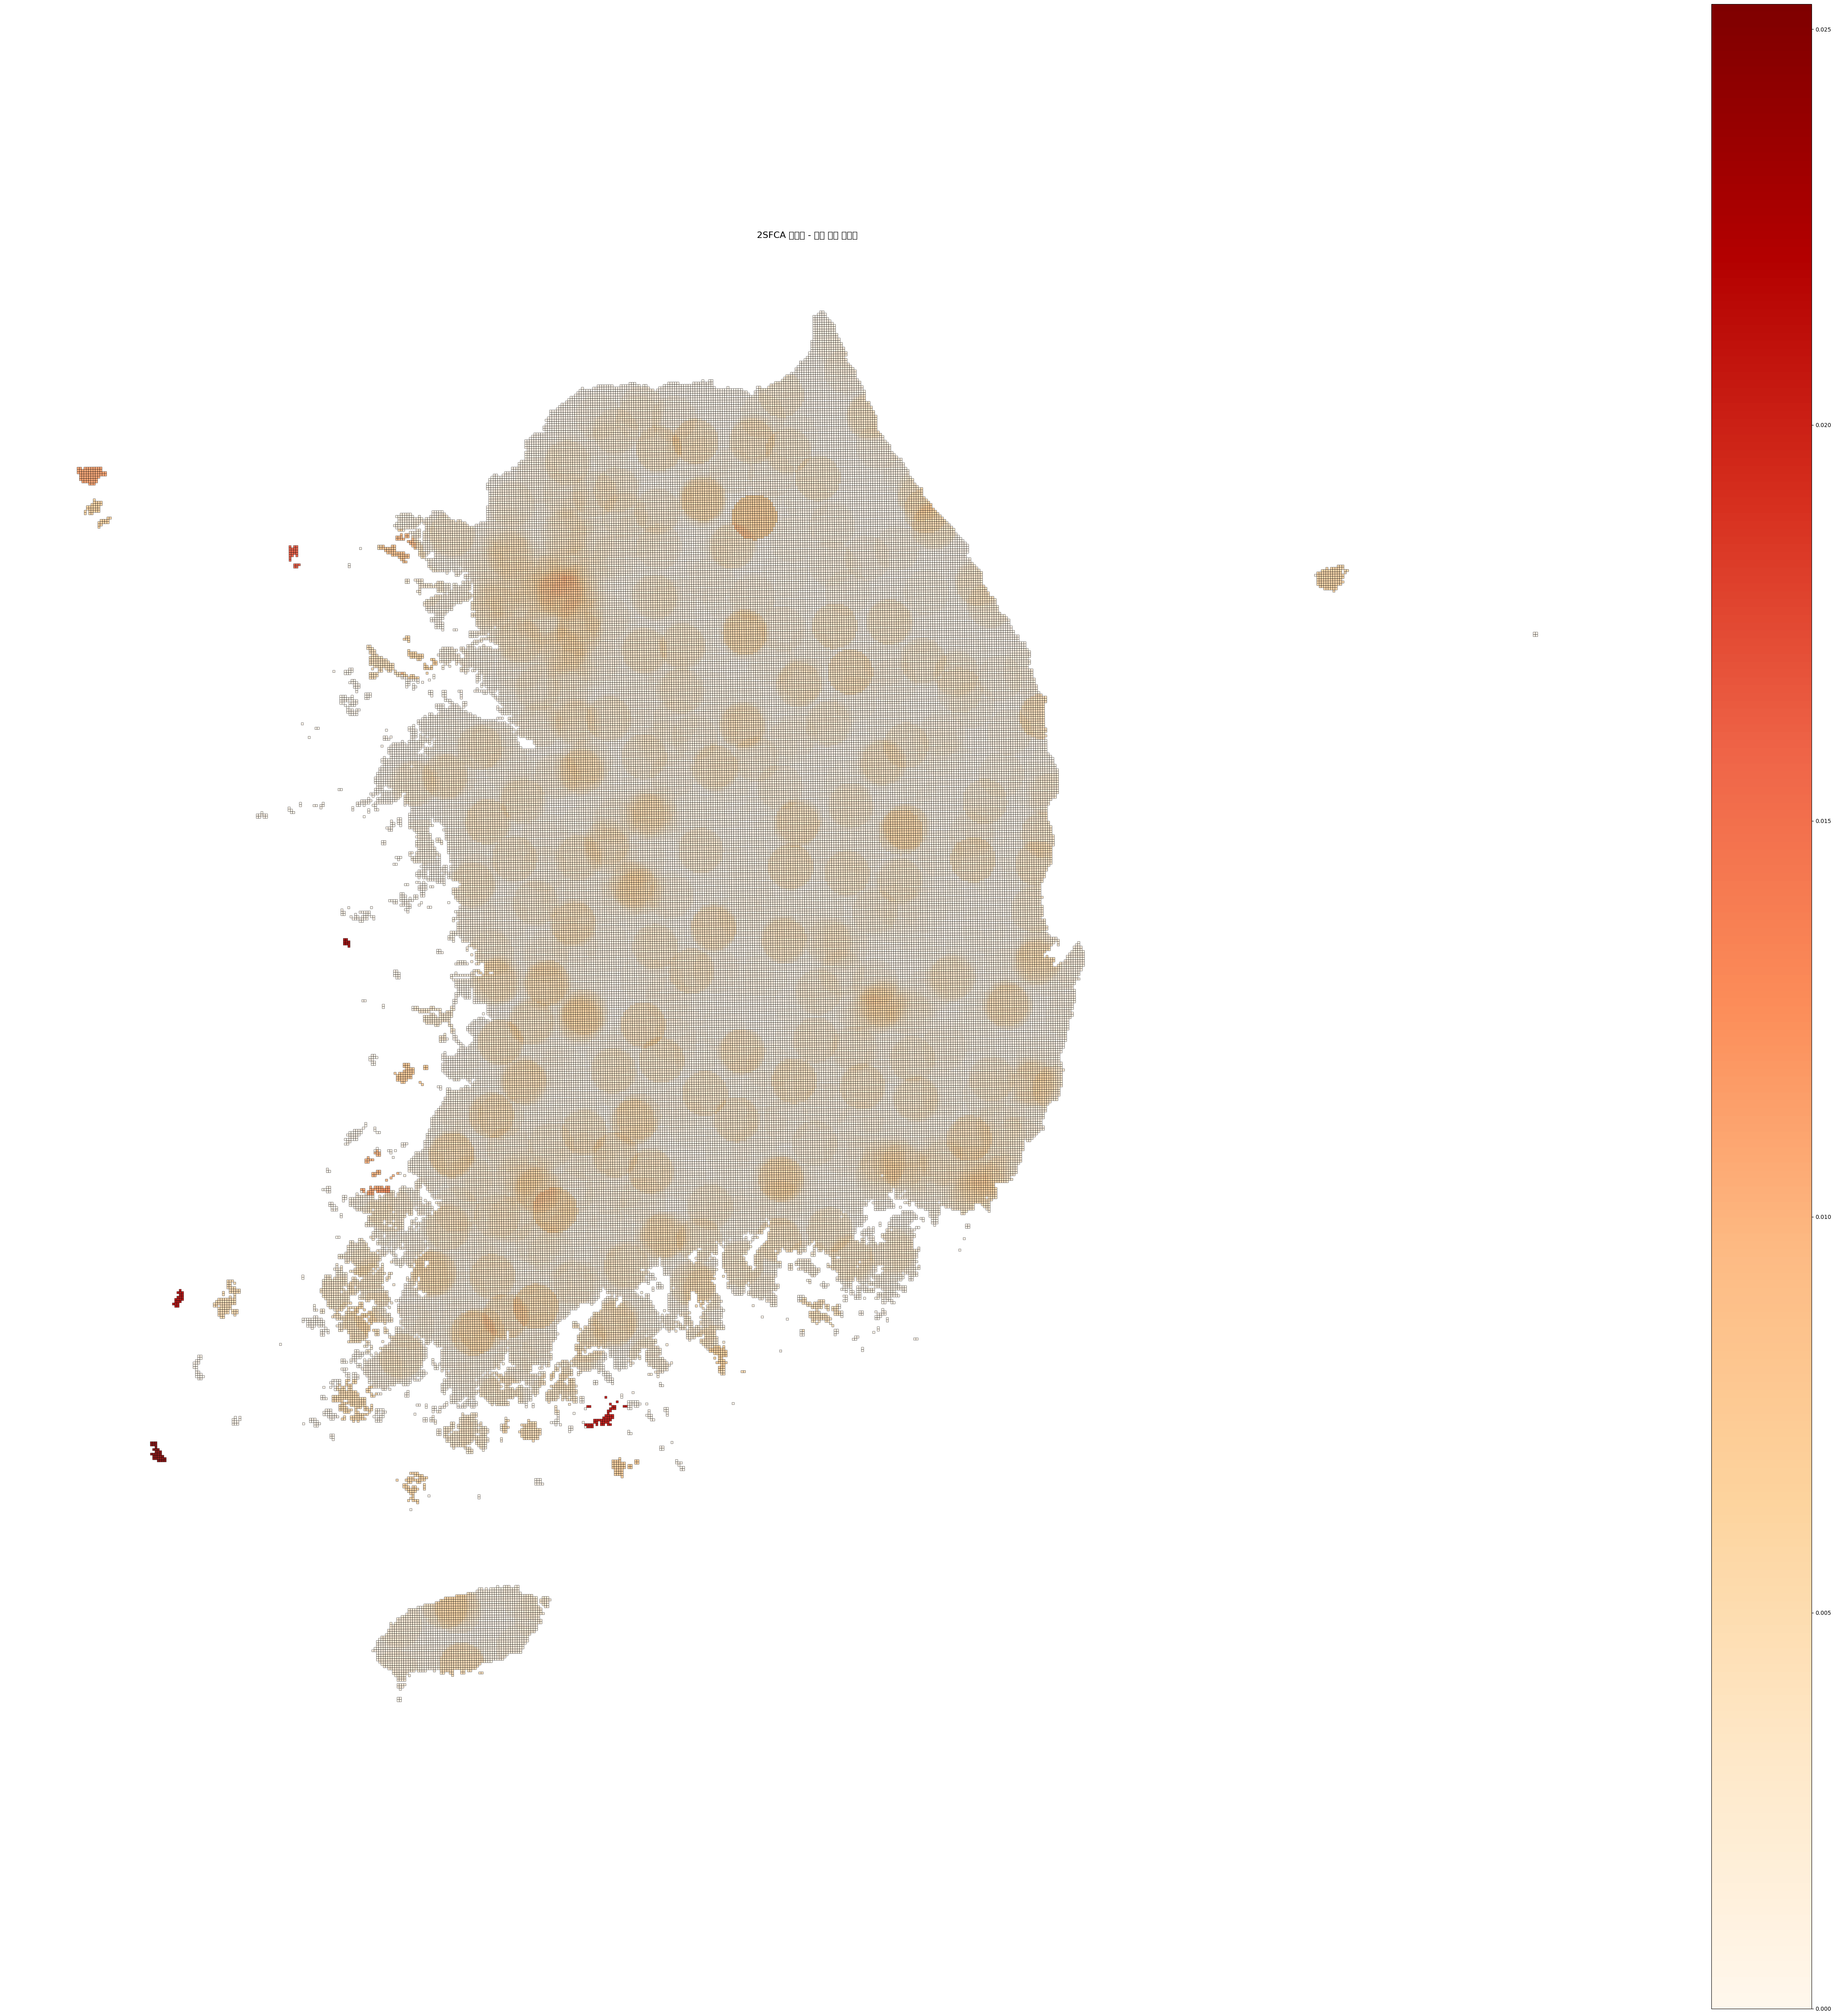

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
gdf = gpd.read_file("grid_with_accessibility_1K.gpkg")

# 2. figure 사이즈 키우기
fig, ax = plt.subplots(1, 1, figsize=(50, 50))  # 가로x세로 (inch)

# # 3. 이상값 제한 (optional)
# vmin = gdf["accessibility_index"].quantile(0.05)
# vmax = gdf["accessibility_index"].quantile(0.5)


gdf.plot(
    column="accessibility_index",
    cmap="OrRd",
    legend=True,
    linewidth=0.4,
    edgecolor="black",  # 경계선 강조
    alpha=0.9,           # 불투명하게
    ax=ax
)

ax.set_title("2SFCA 접근성 - 격자 기반 시각화", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# GeoJSON 파일 읽기
gdf = gpd.read_file("grid_with_elderly.gpkg")

# 내용 확인
print(gdf)
print(gdf.columns)
print(gdf.crs)  # 좌표계 확인

       GRID_1K_CD  elderly_pop  \
0          가다7964            0   
1          가다8064           20   
2          가다8164          108   
3          가다8264            0   
4          가다7765            0   
...           ...          ...   
107656     사사0154            5   
107657     사사0254            0   
107658     사사0055            0   
107659     사사0155            0   
107660     사사0255            0   

                                                 geometry  
0       POLYGON ((779000 1564000, 779000 1565000, 7800...  
1       POLYGON ((780000 1564000, 780000 1565000, 7810...  
2       POLYGON ((781000 1564000, 781000 1565000, 7820...  
3       POLYGON ((782000 1564000, 782000 1565000, 7830...  
4       POLYGON ((777000 1565000, 777000 1566000, 7780...  
...                                                   ...  
107656  POLYGON ((1301000 1954000, 1301000 1955000, 13...  
107657  POLYGON ((1302000 1954000, 1302000 1955000, 13...  
107658  POLYGON ((1300000 1955000, 1300000 1956000,

In [6]:
print("총 격자 수:", len(gdf_all))
print("고유 격자 수:", gdf_all["GRID_1K_CD"].nunique())

# 격자 ID 중복 여부
dupes = gdf_all["GRID_1K_CD"].duplicated(keep=False)
print("중복 격자 수:", dupes.sum())

# 고령 인구 분포 확인
print(gdf_all["elderly_pop"].describe())

# 병합이 이상하게 되었는지 샘플 보기
print(gdf_all.sort_values("elderly_pop", ascending=False)[["GRID_1K_CD", "elderly_pop"]].head())


총 격자 수: 107661
고유 격자 수: 107661
중복 격자 수: 0
count    107661.000000
mean        210.042169
std        1105.984854
min           0.000000
25%           0.000000
50%          10.000000
75%          49.000000
max       21264.000000
Name: elderly_pop, dtype: float64
      GRID_1K_CD  elderly_pop
39841     다사6748        21264
39253     다사5142        20767
39816     다사4248        19764
39349     다사4943        19500
39446     다사4944        19494


In [7]:
print(gdf_all["elderly_pop"].describe())

count    107661.000000
mean        210.042169
std        1105.984854
min           0.000000
25%           0.000000
50%          10.000000
75%          49.000000
max       21264.000000
Name: elderly_pop, dtype: float64


In [8]:
gdf.sort_values("elderly_pop", ascending=False)[["GRID_1K_CD", "elderly_pop"]].head(10)

,GRID_1K_CD,elderly_pop
39841,다사6748,21264
39253,다사5142,20767
39816,다사4248,19764
39349,다사4943,19500
39446,다사4944,19494
40257,다사4853,19118
40538,다사4856,18817
39815,다사4148,18469
40440,다사4855,18447
39910,다사4149,18072
